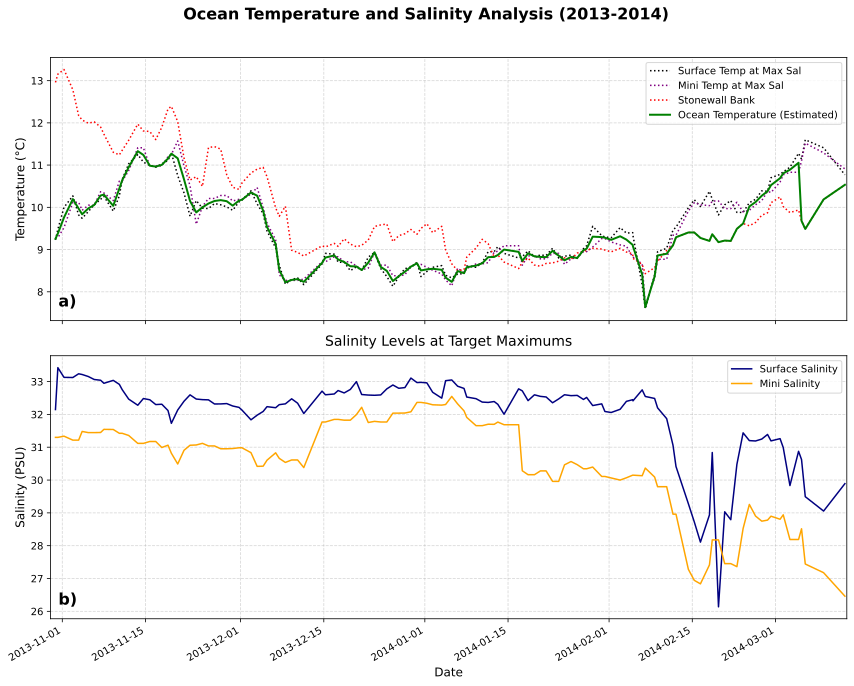

In [1]:
import pandas as pd
import scipy.io as sio
from scipy import signal
from scipy import stats
import numpy as np
import datetime
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import re
%config InlineBackend.figure_format = 'svg'

# Load dataset
downRiverDF = pd.read_csv('downriver_2013_2014_processed.csv', parse_dates = ['DN'])

# --- CUT OUT THE DIPS ---
# Drop the specific bad data dates completely from the dataframe
dips_to_remove = ['2014-02-13', '2014-03-07', '2014-03-08', '2014-03-10', '2014-03-11']
downRiverDF = downRiverDF[~downRiverDF['DN'].dt.strftime('%Y-%m-%d').isin(dips_to_remove)].reset_index(drop=True)
# ------------------------

correlation = signal.correlate(downRiverDF["BottomPressure"].ffill().bfill().to_numpy(), downRiverDF["SurfaceSalCorrected"].ffill().bfill().to_numpy(), mode="full")
lags = signal.correlation_lags(downRiverDF["BottomPressure"].ffill().bfill().to_numpy().size, downRiverDF["SurfaceSalCorrected"].ffill().bfill().to_numpy().size, mode="full") 
lag = lags[np.argmax(correlation)]
res = stats.pearsonr(downRiverDF["BottomPressure"].ffill().bfill().to_numpy(), downRiverDF["SurfaceSalCorrected"].ffill().bfill().to_numpy())

#reading in flow data
flowDF = pd.read_csv('2013_2014alsea.csv')
flowDF['fRate'] = flowDF['max_va'] * 0.0283168
#create a new column for flow dates
for index, row in flowDF.iterrows():
    calcDate = pd.Timestamp(year=int(row['begin_yr']), month=int(row['month_nu']), day=int(row['day_nu']))
    flowDF.loc[index, 'DN'] = calcDate

minilanderDF = pd.read_csv('minilander_2013_2014_processed.csv', parse_dates = ['DN'])

# USING SURFACE SALINITY DUE TO POOR BOTTOM SALNITY DATA

#create day DN to separate out data values by day instead of 5 min intervals
downRiverDF['dayDN'] = downRiverDF['DN'].dt.floor('D')
minilanderDF['dayDN'] = minilanderDF['DN'].dt.floor('D')
#takes highest sal values by day and collects idx, then converts floats to integers
idxMaxDownArray = downRiverDF.groupby("dayDN")["SurfaceSalCorrected"].idxmax().ffill().astype('Int64').to_numpy()
idxMaxMiniArray = minilanderDF.groupby("dayDN")["Salinity"].idxmax().ffill().bfill().astype('Int64').to_numpy()

#filter data frame from NAN duplicates created in previous step
salToTempDownDF = downRiverDF.loc[idxMaxDownArray].drop_duplicates()
salToTempMiniDF = minilanderDF.loc[idxMaxMiniArray].drop_duplicates()

#trying to combine so that both arrays are same length
combinedDF = pd.merge_asof(salToTempDownDF, salToTempMiniDF, on = 'DN')[["DN", "SurfaceTemp", "Temperature", "SurfaceSalCorrected", "Salinity"]]
maxDN = combinedDF["DN"].max()
# adding empty columns to allow for concat to work
salToTempMiniDF["SurfaceTemp"] = np.nan
salToTempMiniDF["SurfaceSalCorrected"] = np.nan
#combining tail of minilander data to other data
combinedDF = pd.concat([combinedDF, salToTempMiniDF.loc[salToTempMiniDF['DN']>maxDN][["DN", "SurfaceTemp", "Temperature", "SurfaceSalCorrected", "Salinity"]]])

#STONEWALL BANK OCEAN TEMPERATURE
stonewallDF = pd.concat([pd.read_csv('2013_2014_stonewallbank.csv'), pd.read_csv('2014_stonewall.csv')])
# format time series
stonewallDF["dayDN"] = (pd.to_datetime(stonewallDF['YY'].astype(str) + '/' + stonewallDF['MM'].astype(str) + '/' + stonewallDF['DD'].astype(str) + '/' , format='mixed'))
# isolate and group by average value for that day
dailyStonewallDF = stonewallDF.groupby("dayDN").agg(dailyAverage = ("WTMP", "mean")).reset_index()

# --- FIXED: Cast to Series astype directly, removing '.dt' ---
combinedDF["DN"] = pd.to_datetime(combinedDF["DN"]).astype('datetime64[ns]')
dailyStonewallDF["dayDN"] = pd.to_datetime(dailyStonewallDF["dayDN"]).astype('datetime64[ns]')
flowDF["DN"] = pd.to_datetime(flowDF["DN"]).astype('datetime64[ns]')

# Sort dataframes before using merge_asof to avoid errors
combinedDF = combinedDF.sort_values("DN")
dailyStonewallDF = dailyStonewallDF.sort_values("dayDN")
flowDF = flowDF.sort_values("DN")

# Merge data streams together cleanly
combinedDF = pd.merge_asof(combinedDF, dailyStonewallDF, left_on = "DN", right_on = "dayDN")
combinedDF = pd.merge_asof(combinedDF, flowDF[["DN", "fRate"]], on="DN")

# --- OPTIMIZED: Vectorized calculations instead of iterrows loops ---
# 1. Calculate Ocean Salinity Estimate (Average of SurfaceSalCorrected and Salinity, ignoring NaNs)
combinedDF["oceanSalEstimate"] = combinedDF[["SurfaceSalCorrected", "Salinity"]].mean(axis=1)

# 2. Calculate Ocean Temperature Estimate based on the flow threshold rule
# Default calculation setup: average of SurfaceTemp and Temperature (ignoring NaNs)
normal_temp_avg = combinedDF[["SurfaceTemp", "Temperature"]].mean(axis=1)

# If fRate > 100 m^3/s, use dailyAverage (Stonewall Bank), otherwise use the normal average setup
combinedDF["AvgEstimatedTemp"] = np.where(
    combinedDF["fRate"] > 100, 
    combinedDF["dailyAverage"], 
    normal_temp_avg
)
# -------------------------------------------------------------------
combinedDF.to_csv('ocean_temperature13_14.csv', index=False)
# Create the figure and subplots (2 rows, 1 column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# ----------------------------------------------------
# Subplot 1: Temperatures
# ----------------------------------------------------
ax1.plot(combinedDF['DN'], combinedDF['SurfaceTemp'], color='black', linestyle=':', label='Surface Temp at Max Sal')
ax1.plot(combinedDF['DN'], combinedDF['Temperature'], color='purple', linestyle=':', label='Mini Temp at Max Sal')
ax1.plot(combinedDF['DN'], combinedDF['dailyAverage'], color='red', linestyle=':', label='Stonewall Bank')
ax1.plot(combinedDF['DN'], combinedDF['AvgEstimatedTemp'], color='green', linewidth=2, label='Ocean Temperature (Estimated)')

ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# Panel label a) in the top-left corner
ax1.text(0.01, 0.10, 'a)', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

# ----------------------------------------------------
# Subplot 2: Salinities
# ----------------------------------------------------
ax2.plot(combinedDF['DN'], combinedDF['SurfaceSalCorrected'], color='navy', linestyle='-', label='Surface Salinity')
ax2.plot(combinedDF['DN'], combinedDF['Salinity'], color='orange', linestyle='-', label='Mini Salinity')

ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Salinity (PSU)', fontsize=12)
ax2.set_title('Salinity Levels at Target Maximums', fontsize=14, pad=10)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

# Panel label b) in the top-left corner
ax2.text(0.01, 0.10, 'b)', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

# ----------------------------------------------------
# Global Layout Adjustments
# ----------------------------------------------------
plt.suptitle('Ocean Temperature and Salinity Analysis (2013-2014)', fontsize=16, fontweight='bold', y=0.95)
fig.autofmt_xdate(rotation=30)  # Rotate date labels cleanly

# Match the x-axis limits used in your Plotly graph
ax2.set_xlim(pd.Timestamp('2013-10-30'), pd.Timestamp('2014-03-13'))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()